# PyRolL Pillar Model Intro
This notebook demonstrates the basic usage of the `pyroll-pillar-model` plugin. Features of the plugin are the calculation of the material flow of symmetrical two roll passes using pillar-elements. Further, the velocity profile of the `roll_pass` is calculated according to volume conservation.  <br>

## Initialisation and Configuration
At first, we will load the plugin and go over the different possibilities. 



In [27]:
import math
import matplotlib.pyplot as plt
from copy import copy

from shapely import clip_by_rect

In [3]:
import pyroll.core as pr
import pyroll.pillar_model
import pyroll.neutral_point_estimator

from pyroll.core import RollPass

## Setting Model Parameters
At first, we will take a look at the model parameters and their respective default value: 
<br>
- `PILLAR_COUNT` - 30
- `PILLAR_TYPE` - `EQUIDISTANT`
- `ELONGATION_CORRECTION` - `True`
<br>
The first sets the amount of pillar elements used to discretize the profile. Any `int`value is supported here.
The second, is the pillar type, here two types are distinguished. Uniform (`UNIFORM`) creates pillar elements, that have a uniform area, the second option is equidistant (`EQUIDISTANT`) which will create pillar elements having the same width. The last configuration option is `ELONGATION_CORRECTION` is set to `True`, the pillar model will correct the elongation using the model of J Gorecki, (Gorecki J. Hutnik 1951, S.179).
Let's define a profile and check the influence of these values. 

In [4]:
pyroll.pillar_model.Config.PILLAR_TYPE = "EQUIDISTANT"
pyroll.pillar_model.Config.PILLAR_COUNT = 10

In [5]:
three_high_in_profile_equidistant_pillars = pr.Profile.square(
    side=45e-3,
    corner_radius=3e-3,
    temperature=1100 + 273.15,
    strain=0,
    material=["C45", "steel"],
    density=7.5e3,
    specific_heat_capacity=690,
    flow_stress=100e6
)
three_high_in_profile_equidistant_pillars.pillar_areas

array([1.96834313e-04, 1.84114160e-04, 1.63394758e-04, 1.42675357e-04,
       1.21955956e-04, 1.01236554e-04, 8.05171529e-05, 5.97977516e-05,
       3.90783502e-05, 1.83589488e-05])

In [6]:
continuous_mill_in_profile_equidistant_pillars = pr.Profile.round(
    radius=24e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["C45", "steel"],
    density=7.5e3,
    specific_heat_capacity=690,
    flow_stress=100e6
)
continuous_mill_in_profile_equidistant_pillars.pillar_areas

array([1.21263158e-04, 1.20548904e-04, 1.18464254e-04, 1.14934988e-04,
       1.09831953e-04, 1.02952912e-04, 9.39907957e-05, 8.17676148e-05,
       6.52184454e-05, 3.84448334e-05])

In [7]:
pyroll.pillar_model.Config.PILLAR_TYPE = "UNIFORM"
pyroll.pillar_model.Config.PILLAR_COUNT = 10

In [8]:
three_high_in_profile_uniform_pillars = pr.Profile.square(
    side=45e-3,
    corner_radius=3e-3,
    temperature=1100 + 273.15,
    strain=0,
    material=["C45", "steel"],
    density=7.5e3,
    specific_heat_capacity=690,
    flow_stress=100e6
)
three_high_in_profile_uniform_pillars.pillar_areas

array([0.00010625, 0.00010625, 0.00010625, 0.00010625, 0.00010625,
       0.00010625, 0.00010625, 0.00010625, 0.00010625, 0.00010625])

In [9]:
continuous_mill_in_profile_uniform_pillars = in_profile = pr.Profile.round(
    radius=24e-3,
    temperature=1200 + 273.15,
    strain=0,
    material=["C45", "steel"],
    density=7.5e3,
    specific_heat_capacity=690,
    flow_stress=100e6
)
continuous_mill_in_profile_uniform_pillars.pillar_areas

array([9.57720015e-05, 9.57720015e-05, 9.57720015e-05, 9.57720015e-05,
       9.57720014e-05, 9.57720014e-05, 9.57720016e-05, 9.57720015e-05,
       9.57720015e-05, 9.57720015e-05])

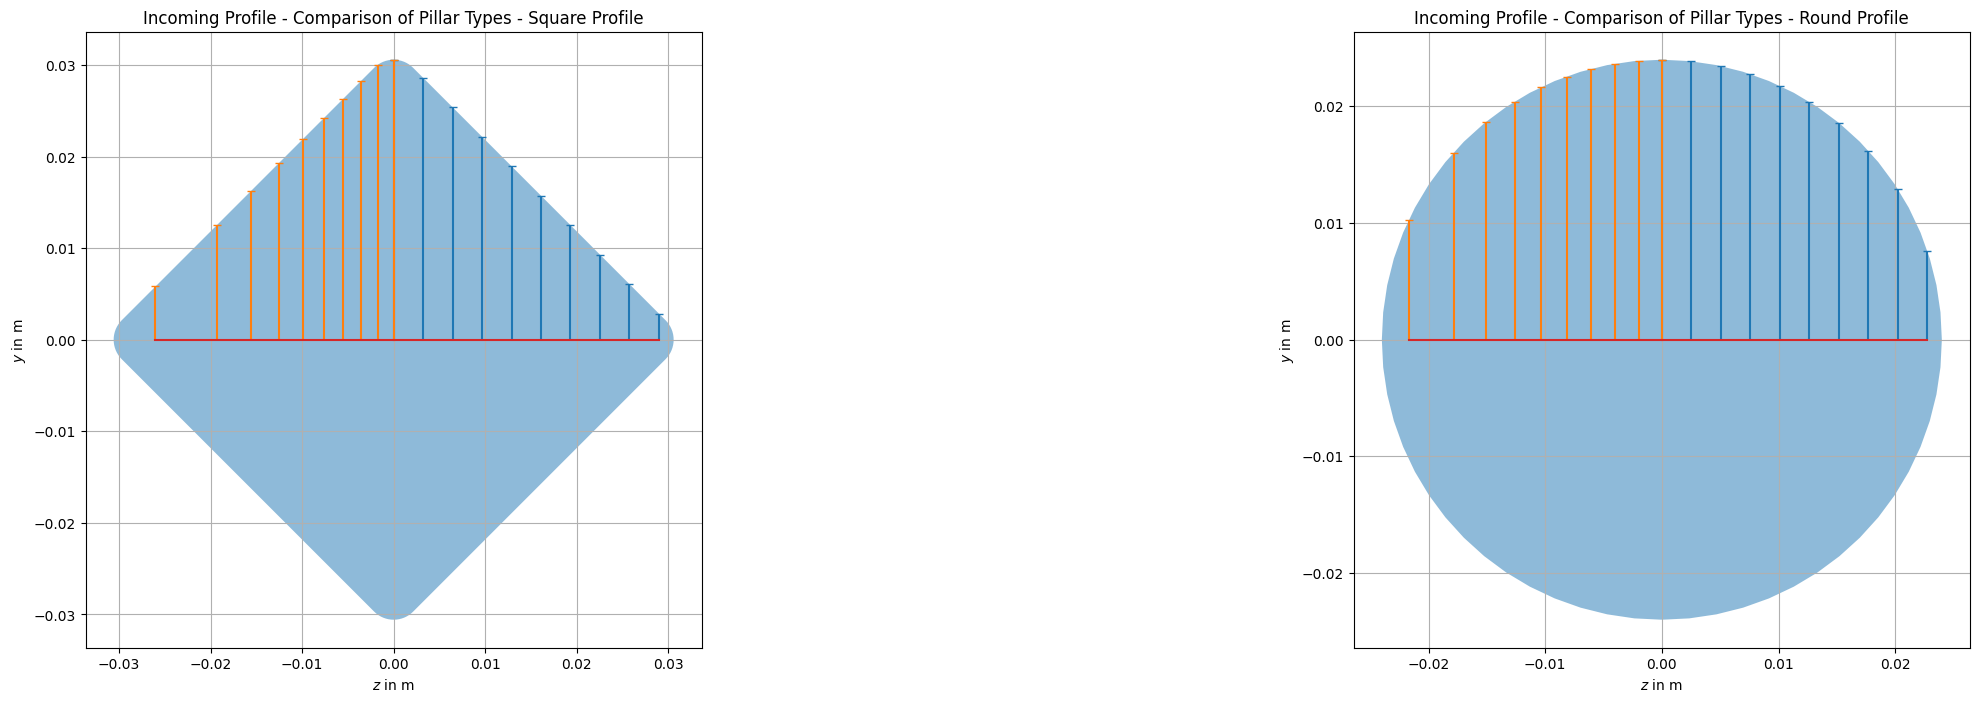

In [32]:
fig, axs = plt.subplots(figsize=(30, 8), nrows=1, ncols=2)

axs[0].set_title(r"Incoming Profile - Comparison of Pillar Types - Square Profile")
axs[0].set_xlabel(r"$z$ in $\mathrm{m}$")
axs[0].set_ylabel(r"$y$ in $\mathrm{m}$")
axs[0].grid(True)
axs[0].set_aspect("equal")

axs[0].fill(*three_high_in_profile_equidistant_pillars.cross_section.exterior.xy, alpha=0.5)
axs[0].stem(three_high_in_profile_equidistant_pillars.pillars,
            three_high_in_profile_equidistant_pillars.pillar_heights / 2, linefmt="C0",
            markerfmt="_")
axs[0].stem(-three_high_in_profile_uniform_pillars.pillars, three_high_in_profile_uniform_pillars.pillar_heights / 2,
            linefmt="C1",
            markerfmt="_")

axs[1].set_title(r"Incoming Profile - Comparison of Pillar Types - Round Profile")
axs[1].set_xlabel(r"$z$ in $\mathrm{m}$")
axs[1].set_ylabel(r"$y$ in $\mathrm{m}$")
axs[1].grid(True)
axs[1].set_aspect("equal")

axs[1].fill(*continuous_mill_in_profile_equidistant_pillars.cross_section.exterior.xy, alpha=0.5)
axs[1].stem(continuous_mill_in_profile_equidistant_pillars.pillars,
            continuous_mill_in_profile_equidistant_pillars.pillar_heights / 2, linefmt="C0",
            markerfmt="_")
axs[1].stem(-continuous_mill_in_profile_uniform_pillars.pillars,
            continuous_mill_in_profile_uniform_pillars.pillar_heights / 2,
            linefmt="C1",
            markerfmt="_")

plt.show()

## Spreading
The pillar model, even though published or mentioned by many others, has not yet been investigated regarding its actual behaviour when calculating the material flow. 
There has been published papers, but these works either just mention the method and give results or they are not available anymore.
Therefore, we will assume an arbitrary spread of the pillars.

In [20]:
@RollPass.DiskElement.pillar_spreads
def pillar_spreads(self: RollPass.DiskElement):
    return self.pillar_draughts ** -0.5

## The Pass Sequences
As common, we define a pass sequence. What is notable, is the usage of disk-elements for calculation of the material flow. 
The pillar-model plugin, uses a simple contact searching algorithm which checks locally along the roll-gap, which pillars are in contact with the groove contour and therefore spread into the direction of the roll-gap.

### Three High Reversing Mill 

As an example, the first pass of the pass sequence for rolling 8 mm round profiles at the three high rolling mill at the Institute of Metal Forming (IMF) is used. 
However, PyRoll is currently only able to simulate symmetrical passes, so the average diameter is used here.


In [21]:
mean_roll_radius_1_lower = (324e-3 + 320e-3) / 2 / 2

In [22]:
DISK_ELEMENT_COUNT = 30

In [23]:
three_high_sequence = pr.PassSequence([
    pr.RollPass(
        label="Raute I",
        roll=pr.Roll(
            groove=pr.DiamondGroove(
                usable_width=76.55e-3,
                tip_depth=22.1e-3,
                r1=12e-3,
                r2=8e-3
            ),
            nominal_radius=mean_roll_radius_1_lower,
        ),
        velocity=1,
        gap=3e-3,
        disk_element_count=DISK_ELEMENT_COUNT
    )
])

### Semi Continuous Mill

As a second example, the first pass of the pass sequence for rolling 8 mm round profiles at the semi-continuous rolling mill at the Institute of Metal Forming (IMF) is used.

In [24]:
continuous_mill_sequence = pr.PassSequence([
    pr.RollPass(
        label="K 02/001 - 1",
        roll=pr.Roll(
            groove=pr.SwedishOvalGroove(
                r1=6e-3,
                r2=26e-3,
                ground_width=38e-3,
                usable_width=60e-3,
                depth=7.25e-3
            ),
            nominal_radius=321e-3 / 2,
            rotational_frequency=0.99,
        ),
        gap=13.5e-3,
        disk_element_count=DISK_ELEMENT_COUNT
    )
])

### Investigation of Different Model Configurations

In [25]:
pyroll.pillar_model.Config.PILLAR_TYPE = "EQUIDISTANT"
pyroll.pillar_model.Config.PILLAR_COUNT = 30

three_high_sequence_equidistant_pillars = copy(three_high_sequence)
three_high_sequence_equidistant_pillars.solve(in_profile=three_high_in_profile_equidistant_pillars)

semi_continuous_sequence_equidistant_pillars = copy(continuous_mill_sequence)
semi_continuous_sequence_equidistant_pillars.solve(in_profile=continuous_mill_in_profile_equidistant_pillars)

Profile(
    classifiers={'generic_elongation', 'oval', 'swedish_oval'},
    cross_section=Polygon(
        area=0.0014792927789902422,
        height=0.02800000000000001,
        perimeter=0.15140676614642107,
        width=0.059466664307781865,
        ),
    density=7500.0,
    flow_stress=100000000.0,
    length=0.0,
    material=['C45', 'steel'],
    specific_heat_capacity=690,
    strain=0.4786229384376691,
    t=0.05590019205234058,
    temperature=1473.15,
    )

In [26]:
pyroll.pillar_model.Config.PILLAR_TYPE = "UNIFORM"
pyroll.pillar_model.Config.PILLAR_COUNT = 30

three_high_sequence_uniform_pillars = copy(three_high_sequence)
three_high_sequence_uniform_pillars.solve(in_profile=three_high_in_profile_uniform_pillars)

semi_continuous_sequence_uniform_pillars = copy(continuous_mill_sequence)
semi_continuous_sequence_uniform_pillars.solve(in_profile=continuous_mill_in_profile_uniform_pillars)

Profile(
    classifiers={'generic_elongation', 'oval', 'swedish_oval'},
    cross_section=Polygon(
        area=0.0014569679234101597,
        height=0.02800000000000001,
        perimeter=0.1494263202592903,
        width=0.05832081701695758,
        ),
    density=7500.0,
    flow_stress=100000000.0,
    length=0.0,
    material=['C45', 'steel'],
    specific_heat_capacity=690,
    strain=0.47512288124468854,
    t=0.05590019205234058,
    temperature=1473.15,
    )

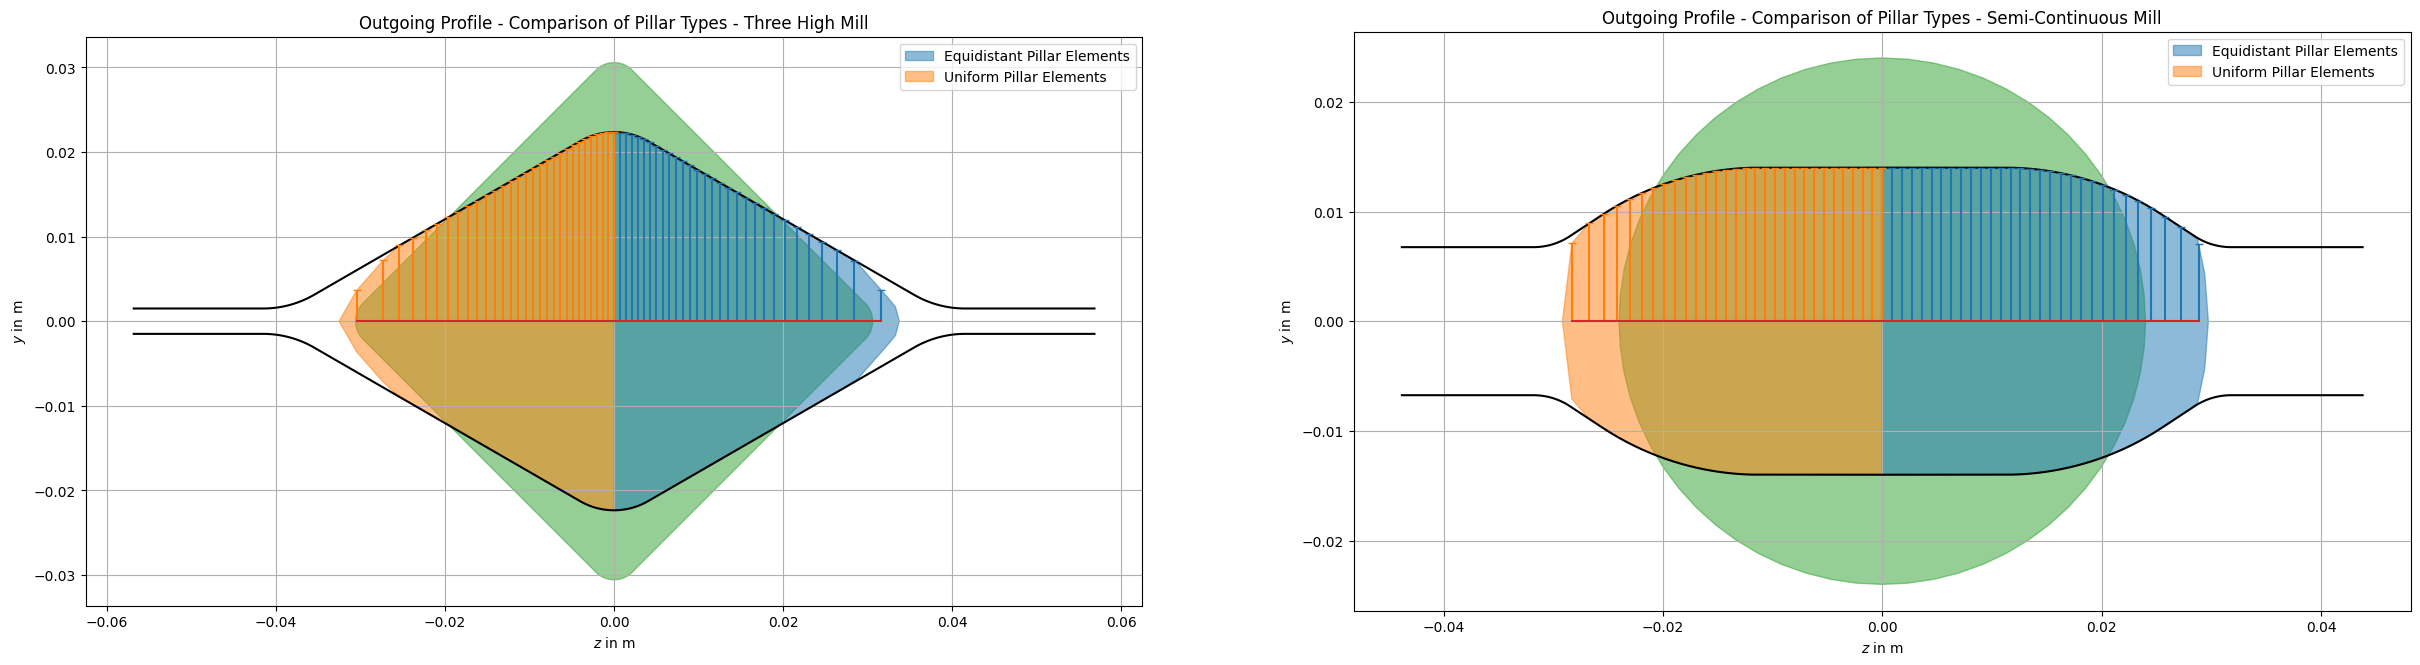

In [36]:
fig, axs = plt.subplots(figsize=(30, 8), nrows=1, ncols=2)

axs[0].set_title(r"Outgoing Profile - Comparison of Pillar Types - Three High Mill")
axs[0].set_xlabel(r"$z$ in $\mathrm{m}$")
axs[0].set_ylabel(r"$y$ in $\mathrm{m}$")
axs[0].grid(True)
axs[0].set_aspect("equal")

three_high_half_uniform_out_profile_cross_section = clip_by_rect(three_high_sequence_uniform_pillars.out_profile.cross_section, -three_high_sequence_equidistant_pillars.out_profile.width / 2, -math.inf, 0, math.inf)
three_high_half_equidistant_out_profile_cross_section = clip_by_rect(three_high_sequence_equidistant_pillars.out_profile.cross_section, 0, -math.inf, three_high_sequence_equidistant_pillars.out_profile.width / 2, math.inf)

for cl in three_high_sequence_uniform_pillars[-1].contour_lines:
    axs[0].plot(*cl.xy, color="black")

axs[0].fill(*three_high_sequence_uniform_pillars.in_profile.cross_section.exterior.xy, alpha=0.5, color="C2")
axs[0].fill(*three_high_half_equidistant_out_profile_cross_section.exterior.xy, alpha=0.5, color="C0", label="Equidistant Pillar Elements")
axs[0].fill(*three_high_half_uniform_out_profile_cross_section.exterior.xy, alpha=0.5, color="C1", label="Uniform Pillar Elements")
axs[0].stem(three_high_sequence_equidistant_pillars.out_profile.pillars, three_high_sequence_equidistant_pillars.out_profile.pillar_heights / 2, linefmt="C0", markerfmt="_")
axs[0].stem(-three_high_sequence_uniform_pillars.out_profile.pillars, three_high_sequence_uniform_pillars.out_profile.pillar_heights / 2, linefmt="C1", markerfmt="_")
axs[0].legend()

axs[1].set_title(r"Outgoing Profile - Comparison of Pillar Types - Semi-Continuous Mill")
axs[1].set_xlabel(r"$z$ in $\mathrm{m}$")
axs[1].set_ylabel(r"$y$ in $\mathrm{m}$")
axs[1].grid(True)
axs[1].set_aspect("equal")

semi_continuous_half_uniform_out_profile_cross_section = clip_by_rect(semi_continuous_sequence_uniform_pillars.out_profile.cross_section, -semi_continuous_sequence_uniform_pillars.out_profile.width / 2, -math.inf, 0, math.inf)
semi_continuous_half_equidistant_out_profile_cross_section = clip_by_rect(semi_continuous_sequence_equidistant_pillars.out_profile.cross_section, 0, -math.inf, semi_continuous_sequence_equidistant_pillars.out_profile.width / 2, math.inf)

for cl in semi_continuous_sequence_uniform_pillars[-1].contour_lines:
    axs[1].plot(*cl.xy, color="black")

axs[1].fill(*semi_continuous_sequence_uniform_pillars.in_profile.cross_section.exterior.xy, alpha=0.5, color="C2")
axs[1].fill(*semi_continuous_half_equidistant_out_profile_cross_section.exterior.xy, alpha=0.5, color="C0", label="Equidistant Pillar Elements")
axs[1].fill(*semi_continuous_half_uniform_out_profile_cross_section.exterior.xy, alpha=0.5, color="C1", label="Uniform Pillar Elements")
axs[1].stem(semi_continuous_sequence_equidistant_pillars.out_profile.pillars, semi_continuous_sequence_equidistant_pillars.out_profile.pillar_heights / 2, linefmt="C0", markerfmt="_")
axs[1].stem(-semi_continuous_sequence_uniform_pillars.out_profile.pillars, semi_continuous_sequence_uniform_pillars.out_profile.pillar_heights / 2, linefmt="C1", markerfmt="_")
axs[1].legend()

plt.show()

### Sensitivity Analysis - Square - Diamond Pass

In [41]:
pyroll.pillar_model.Config.PILLAR_TYPE = "EQUIDISTANT"
PILLAR_COUNTS = [10, 50, 100, 150, 200, 250]
three_high_equidistant_results = {}
for PC in PILLAR_COUNTS:
    three_high_sequence_equidistant_pillars = copy(three_high_sequence)
    three_high_sequence_equidistant_pillars.solve(in_profile=three_high_in_profile_equidistant_pillars)
    three_high_equidistant_results[PC] = three_high_sequence_equidistant_pillars

Solution iteration of RollPass 'Raute I' exceeded the maximum iteration count of 100. Continuing anyway.


In [42]:
pyroll.pillar_model.Config.PILLAR_TYPE = "UNIFORM"
PILLAR_COUNTS = [10, 50, 100, 150, 200, 250]
three_high_uniform_results = {}
for PC in PILLAR_COUNTS:
    three_high_sequence_uniform_pillars = copy(three_high_sequence)
    three_high_sequence_uniform_pillars.solve(in_profile=three_high_in_profile_uniform_pillars)
    three_high_uniform_results[PC] = three_high_sequence_uniform_pillars

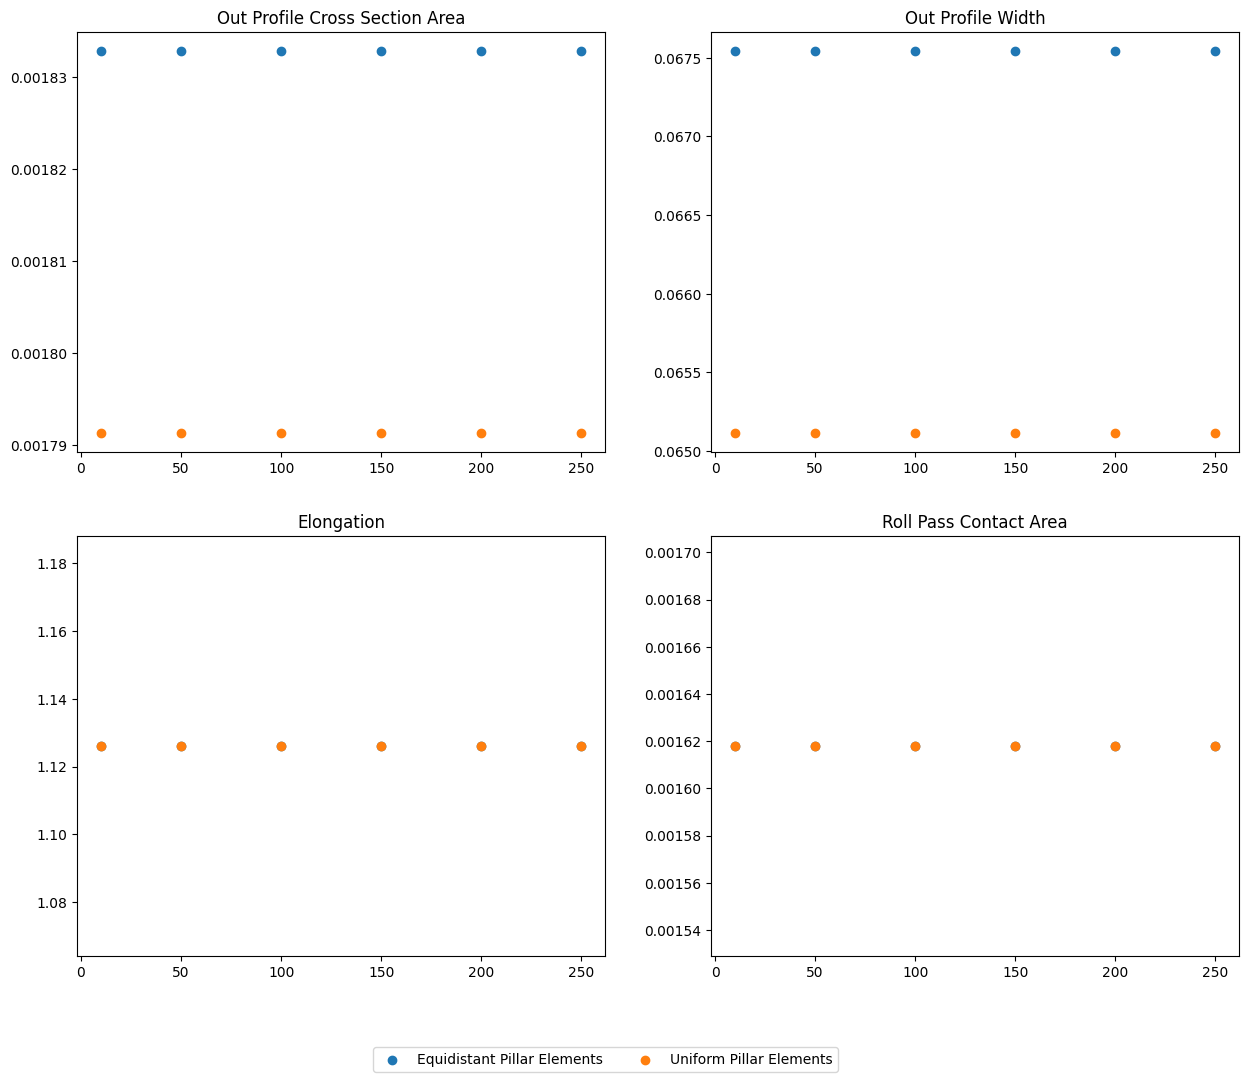

In [43]:
fig, ax = plt.subplots(figsize=(15, 12), nrows=2, ncols=2)

for key in uniform_results.keys():
    ax[0, 0].scatter(key, three_high_equidistant_results[key].out_profile.cross_section.area, color="C0")
    ax[0, 0].scatter(key, three_high_uniform_results[key].out_profile.cross_section.area, color="C1")
    ax[0, 0].set_title("Out Profile Cross Section Area")
    ax[0, 0].grid()

    ax[0, 1].scatter(key, three_high_equidistant_results[key].out_profile.width, color="C0")
    ax[0, 1].scatter(key, three_high_uniform_results[key].out_profile.width, color="C1")
    ax[0, 1].set_title("Out Profile Width")
    ax[0, 1].grid()

    ax[1, 0].scatter(key, three_high_equidistant_results[key][-1].elongation, color="C0")
    ax[1, 0].scatter(key, three_high_uniform_results[key][-1].elongation, color="C1")
    ax[1, 0].set_title("Elongation")
    ax[1, 0].grid()

    ax[1, 1].scatter(key, three_high_equidistant_results[key][-1].roll.contact_area, color="C0")
    ax[1, 1].scatter(key, three_high_uniform_results[key][-1].roll.contact_area, color="C1")
    ax[1, 1].set_title("Roll Pass Contact Area")
    ax[1, 1].grid()

ax[1, 1].legend(labels=['Equidistant Pillar Elements', 'Uniform Pillar Elements'], loc='upper center',
                bbox_to_anchor=(-0.2, -0.2), ncol=2)

plt.show()

### Sensitivity Analysis - Round - Oval Pass

In [45]:
pyroll.pillar_model.Config.PILLAR_TYPE = "EQUIDISTANT"
PILLAR_COUNTS = [10, 50, 100, 150, 200, 250]
semi_continuous_equidistant_results = {}
for PC in PILLAR_COUNTS:
    semi_continuous_sequence_equidistant_pillars = copy(continuous_mill_sequence)
    semi_continuous_sequence_equidistant_pillars.solve(in_profile=continuous_mill_in_profile_equidistant_pillars)
    semi_continuous_equidistant_results[PC] = semi_continuous_sequence_equidistant_pillars

Solution iteration of RollPass 'K 02/001 - 1' exceeded the maximum iteration count of 100. Continuing anyway.
Solution iteration of RollPass 'K 02/001 - 1' exceeded the maximum iteration count of 100. Continuing anyway.


In [46]:
pyroll.pillar_model.Config.PILLAR_TYPE = "UNIFORM"
PILLAR_COUNTS = [10, 50, 100, 150, 200, 250]
semi_continuous_uniform_results = {}
for PC in PILLAR_COUNTS:
    semi_continuous_sequence_uniform_pillars = copy(continuous_mill_sequence)
    semi_continuous_sequence_uniform_pillars.solve(in_profile=continuous_mill_in_profile_uniform_pillars)
    semi_continuous_uniform_results[PC] = semi_continuous_sequence_uniform_pillars

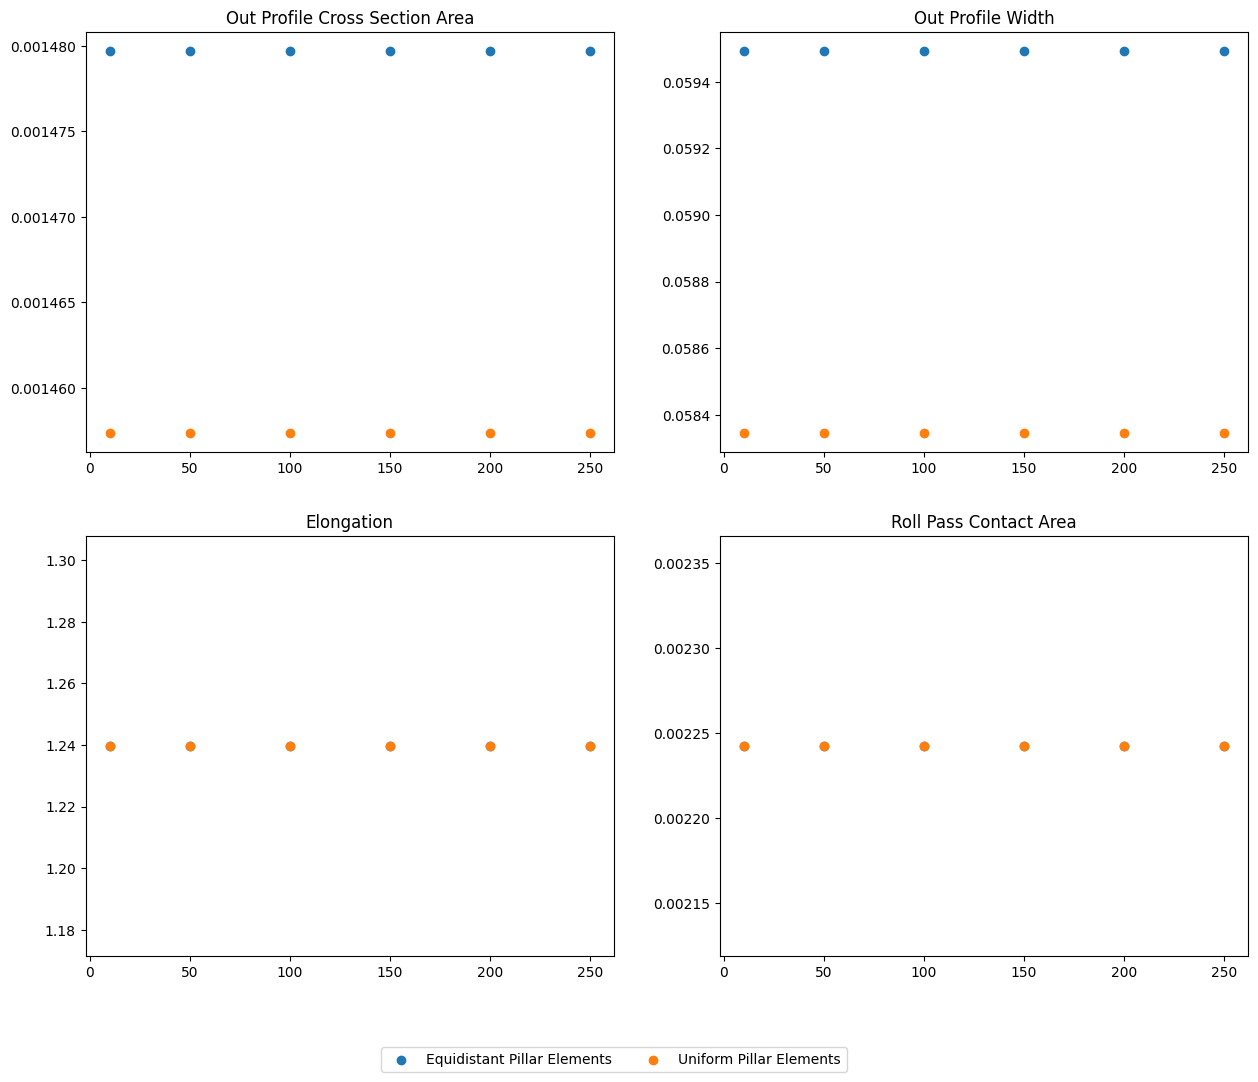

In [47]:
fig, ax = plt.subplots(figsize=(15, 12), nrows=2, ncols=2)

for key in uniform_results.keys():
    ax[0, 0].scatter(key, semi_continuous_equidistant_results[key].out_profile.cross_section.area, color="C0")
    ax[0, 0].scatter(key, semi_continuous_uniform_results[key].out_profile.cross_section.area, color="C1")
    ax[0, 0].set_title("Out Profile Cross Section Area")
    ax[0, 0].grid()

    ax[0, 1].scatter(key, semi_continuous_equidistant_results[key].out_profile.width, color="C0")
    ax[0, 1].scatter(key, semi_continuous_uniform_results[key].out_profile.width, color="C1")
    ax[0, 1].set_title("Out Profile Width")
    ax[0, 1].grid()

    ax[1, 0].scatter(key, semi_continuous_equidistant_results[key][-1].elongation, color="C0")
    ax[1, 0].scatter(key, semi_continuous_uniform_results[key][-1].elongation, color="C1")
    ax[1, 0].set_title("Elongation")
    ax[1, 0].grid()

    ax[1, 1].scatter(key, semi_continuous_equidistant_results[key][-1].roll.contact_area, color="C0")
    ax[1, 1].scatter(key, semi_continuous_uniform_results[key][-1].roll.contact_area, color="C1")
    ax[1, 1].set_title("Roll Pass Contact Area")
    ax[1, 1].grid()

ax[1, 1].legend(labels=['Equidistant Pillar Elements', 'Uniform Pillar Elements'], loc='upper center',
                bbox_to_anchor=(-0.2, -0.2), ncol=2)

plt.show()